# UCB Movie Recommendation Bandit Project

This notebook demonstrates the full pipeline for a movie recommendation system using the Upper Confidence Bound (UCB) bandit algorithm.

## 1. Import Required Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

## 2. Load and Explore the MovieLens Dataset

In [7]:
# Data loader for MovieLens 100K

def load_data(data_dir='dataset'):
    data_path = os.path.join(data_dir, 'u.data')
    item_path = os.path.join(data_dir, 'u.item')
    ratings_cols = ['user_id', 'movie_id', 'rating', 'timestamp']
    ratings_df = pd.read_csv(data_path, sep='\t', names=ratings_cols, encoding='latin-1')
    item_cols = ['movie_id', 'title', 'release_date', 'video_release_date', 'IMDb_URL', 
                 'unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 
                 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 
                 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
    movies_df = pd.read_csv(item_path, sep='|', names=item_cols, encoding='latin-1', usecols=['movie_id', 'title'])
    return ratings_df, movies_df

ratings, movies = load_data()
print('Ratings shape:', ratings.shape)
print('Movies shape:', movies.shape)
ratings.head()

Ratings shape: (100000, 4)
Movies shape: (1682, 2)


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


## 3. Preprocess the Data

In [8]:
def create_rating_matrix(ratings_df):
    rating_matrix = ratings_df.pivot(index='user_id', columns='movie_id', values='rating')
    rating_matrix = rating_matrix.fillna(0)
    return rating_matrix

def normalize_ratings(rating_matrix):
    binary_matrix = (rating_matrix >= 4.0).astype(float)
    return binary_matrix

def preprocess_data(ratings_df):
    rating_matrix = create_rating_matrix(ratings_df)
    normalized_matrix = normalize_ratings(rating_matrix)
    return normalized_matrix

normalized_matrix = preprocess_data(ratings)
print('Normalized matrix shape:', normalized_matrix.shape)
normalized_matrix.iloc[:5, :5]

Normalized matrix shape: (943, 1682)


movie_id,1,2,3,4,5
user_id,,,,,
1,1.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0
5,1.0,0.0,0.0,0.0,0.0


## 4. Define the UCB Bandit Algorithm

In [9]:
import math

class UCBBandit:
    def __init__(self, n_movies):
        self.n_movies = n_movies
        self.t = 0
        self.n_selections = np.zeros(n_movies)
        self.total_rewards = np.zeros(n_movies)
        self.average_reward = np.zeros(n_movies)
    def select_movie(self):
        unexplored_movies = np.where(self.n_selections == 0)[0]
        if len(unexplored_movies) > 0:
            return np.random.choice(unexplored_movies)
        exploration_term = np.sqrt((2 * math.log(self.t)) / self.n_selections)
        ucb_values = self.average_reward + exploration_term
        max_value = np.max(ucb_values)
        best_movies = np.where(ucb_values == max_value)[0]
        return np.random.choice(best_movies)
    def update(self, movie_idx, reward):
        self.t += 1
        self.n_selections[movie_idx] += 1
        self.total_rewards[movie_idx] += reward
        self.average_reward[movie_idx] = self.total_rewards[movie_idx] / self.n_selections[movie_idx]
    def get_top_k_recommendations(self, k=5):
        return np.argsort(self.average_reward)[-k:][::-1]

## 5. Simulate Recommendations with the UCB Bandit

In [10]:
def simulate_recommendations(rating_matrix, bandit, num_steps=10000):
    if hasattr(rating_matrix, 'values'):
        matrix_values = rating_matrix.values
    else:
        matrix_values = rating_matrix
    num_users = matrix_values.shape[0]
    rewards = np.zeros(num_steps)
    optimal_rewards = np.zeros(num_steps)
    selected_movies = np.zeros(num_steps, dtype=int)
    for t in range(num_steps):
        user_idx = np.random.randint(0, num_users)
        movie_idx = bandit.select_movie()
        reward = matrix_values[user_idx, movie_idx]
        optimal_reward = np.max(matrix_values[user_idx, :])
        bandit.update(movie_idx, reward)
        rewards[t] = reward
        optimal_rewards[t] = optimal_reward
        selected_movies[t] = movie_idx
        if (t + 1) % 5000 == 0:
            print(f"Step {t + 1}/{num_steps} completed.")
    return rewards, optimal_rewards, selected_movies

n_movies = normalized_matrix.shape[1]
bandit = UCBBandit(n_movies)
rewards, optimal_rewards, selected_movies = simulate_recommendations(normalized_matrix, bandit, num_steps=20000)

Step 5000/20000 completed.
Step 10000/20000 completed.
Step 15000/20000 completed.
Step 20000/20000 completed.


## 6. Evaluate and Visualize Results

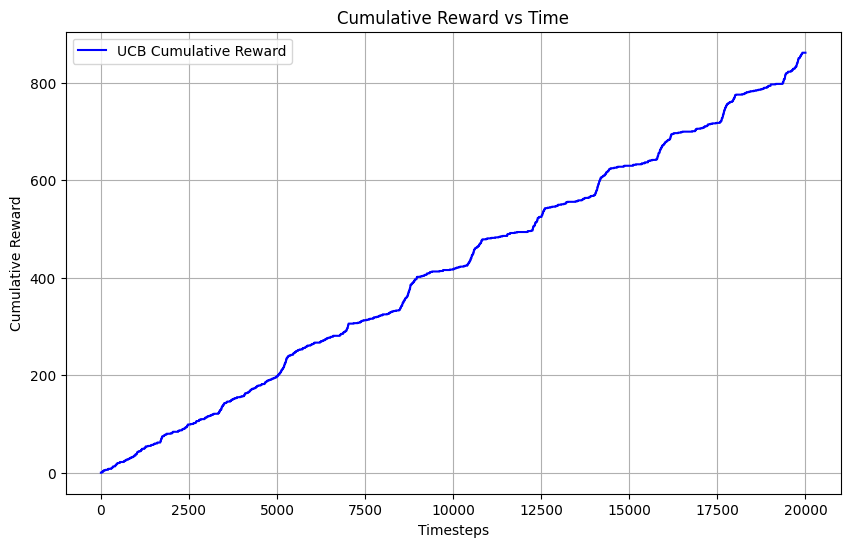

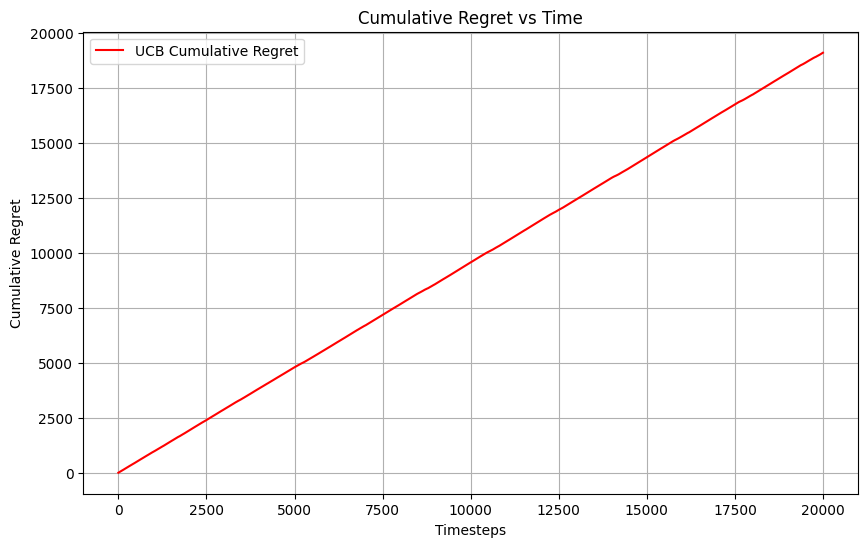

In [11]:
def calculate_metrics(rewards, optimal_rewards):
    cumulative_rewards = np.cumsum(rewards)
    cumulative_optimal_rewards = np.cumsum(optimal_rewards)
    regret = optimal_rewards - rewards
    cumulative_regret = np.cumsum(regret)
    return cumulative_rewards, cumulative_regret

def plot_cumulative_reward(cumulative_rewards):
    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_rewards, label='UCB Cumulative Reward', color='blue')
    plt.xlabel('Timesteps')
    plt.ylabel('Cumulative Reward')
    plt.title('Cumulative Reward vs Time')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_regret(cumulative_regret):
    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_regret, label='UCB Cumulative Regret', color='red')
    plt.xlabel('Timesteps')
    plt.ylabel('Cumulative Regret')
    plt.title('Cumulative Regret vs Time')
    plt.legend()
    plt.grid(True)
    plt.show()

cumulative_rewards, cumulative_regret = calculate_metrics(rewards, optimal_rewards)
plot_cumulative_reward(cumulative_rewards)
plot_regret(cumulative_regret)

## 7. Modular Optimizer: Grid Search Example

In [13]:
from typing import Callable, Any, Dict
from itertools import product

class Optimizer:
    def __init__(self, objective_fn: Callable, **kwargs):
        self.objective_fn = objective_fn
        self.kwargs = kwargs
    def optimize(self, *args, **kwargs) -> Any:
        raise NotImplementedError("Subclasses should implement this method.")

class GridSearchOptimizer(Optimizer):
    def __init__(self, objective_fn: Callable, param_grid: Dict[str, list]):
        super().__init__(objective_fn)
        self.param_grid = param_grid
    def optimize(self):
        best_score = float('-inf')
        best_params = None
        keys = list(self.param_grid.keys())
        for values in product(*[self.param_grid[k] for k in keys]):
            params = dict(zip(keys, values))
            score = self.objective_fn(**params)
            if score > best_score:
                best_score = score
                best_params = params
        return best_params, best_score

### Example: Grid Search to Optimize Number of Steps

In [14]:
# Define an objective function for grid search: maximize average reward by tuning num_steps

def objective_fn(num_steps):
    bandit = UCBBandit(n_movies)
    rewards, optimal_rewards, _ = simulate_recommendations(normalized_matrix, bandit, num_steps=num_steps)
    average_reward = np.mean(rewards)
    return average_reward

param_grid = {'num_steps': [2000, 5000, 10000]}
optimizer = GridSearchOptimizer(objective_fn, param_grid)
best_params, best_score = optimizer.optimize()
print('Best params:', best_params)
print('Best average reward:', best_score)

Step 5000/5000 completed.
Step 5000/10000 completed.
Step 10000/10000 completed.
Best params: {'num_steps': 10000}
Best average reward: 0.0402


## 8. Show Top Recommended Movies

In [15]:
top_indices = bandit.get_top_k_recommendations(k=10)
matrix_columns = normalized_matrix.columns
print('Top 10 recommended movies:')
for i in top_indices:
    movie_id = matrix_columns[i]
    title_series = movies.loc[movies['movie_id'] == movie_id, 'title']
    title = title_series.values[0] if len(title_series) > 0 else 'Unknown'
    print(f'- {title} (ID: {movie_id})')

Top 10 recommended movies:
- Fargo (1996) (ID: 100)
- Star Wars (1977) (ID: 50)
- Return of the Jedi (1983) (ID: 181)
- Princess Bride, The (1987) (ID: 173)
- Contact (1997) (ID: 258)
- Monty Python and the Holy Grail (1974) (ID: 168)
- When Harry Met Sally... (1989) (ID: 216)
- Silence of the Lambs, The (1991) (ID: 98)
- Casablanca (1942) (ID: 483)
- L.A. Confidential (1997) (ID: 302)
